# Welcome to ALPETITE!

# Simulation PIPELINE

## File Import

For compatibility purposes, the version of `PETITE` compatible with `ALPETITE` is in this github folder. Install `PETITE` following the instructions at https://github.com/kjkellyphys/PETITE. 

Import `ALPs.py` functions and make sure the `PETITE` home directory and the `VEGAS` pre-computed dictionaries are the appropriate ones. 

In [1]:
from ALPs import *

Python version:  3.11.3
Numpy version:  1.24.2
Vegas version:  6.1.3
PETITE home directory: /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version
VEGAS dictionary directory: /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_400GeV_default/


## Initialization

Initialize the axion shower object by declaring the name of the folder you want to save your simulation in (created by default in the PETITE home folder). 

If arg `experiment` is not given, the experimental parameters are set to SHiP. You can change experimental parameters by either adding/modifying the `experiments` dictionary at the beginning of the `AxionShower` class or providing directly experimental parameters to the shower object initialization. Each shower instantiation will create a hidden "state" file to keep track of the parameters chosen. Take a moment to verify the parameters are the one you desire.

In [2]:
AxSh=AxionShower('data_ALPETITE_tutorial', experiment='BDX')

[State] Loaded existing state from .log_state.pkl

--- Initialized AxionShower State ---
{
    "Lpipe": 3.0,
    "l0": 20.0,
    "A_detector": 0.275,
    "Ecut": 0.3,
    "POT": 1e+22,
    "shower_material": "aluminum",
    "primaries": "electrons",
    "inelastic_on": true,
    "shower_cutoff": 0.05,
    "rho": 2.699,
    "ndensity": 6.0197696296296294e+22,
    "angle_accept": 0.011400096175762518,
    "me": 0.0005109989499999999,
    "alpha_em": 0.007297352573756914,
    "mT": 27,
    "Z_T": 13,
    "A_T": 27,
    "primary_type": "electrons"
}
-------------------------------------



Initialize the particle beam as a list of `PETITE`'s `Particle` objects. All energies are in GeV.

In [6]:
E0 = 10.6 # energy of incident particle in GeV

# Define incident electron
px, py, pz = 0, 0, np.sqrt(E0**2 - m_electron**2)

# dictionary with particle properties
# The crucial keys are 'PID' and 'ID', others are for efficient bookkeeping
particle_dict = {'PID':11, 'ID':0, 'generation_number':0, 'generation_process':'Input'}

#particle object
p0 = Particle([E0, px, py, pz], [0,0,0], particle_dict)

#beam
pbeam=[p0]*10

#You can check the four momenta of the particle using `get_p0()` method
pbeam[1].get_p0()

array([10.6       ,  0.        ,  0.        , 10.59999999])

## Run modes

The `run` method takes two mandatory arguments:

- beam (list): The primary beam particles for this run.
- masses (list): A list of axion masses to generate or manage. Make sure you have `VEGAS` precomputed dictionary for all the masses in your list if you're simulating either 'Ann+Comp' or 'Brem' (vector based processes).

The `run` method has three modes:

- 'run' (Default): Safe "fill-in" mode. For each process and mass, it first checks if the axion data for that mass already exists. If yes, it does nothing for that process. If no, it runs the entire generation pipeline for it.
- 'append': Always generates a new, unique batch of data files, adding to any existing statistics. This is the primary mode for increasing data.
- 'overwrite': Deletes all previous data for the specified masses AND active processes, then generates a new batch.
                  
Batches are initialized with `run_id`. By default, a time stamp is used.
                  
You can further specify which processes to simulate using `active_processes=['Brem', 'Ann+Comp', 'Primakoff']`. By selecting `primary_only=True`, only the primary contributions are generated.

The sampled axions are saved in .pkl files inside folders named by the generation process. Sampled vectors and photons are saved as well. 

In [7]:
AxSh.run(pbeam, [0.1,0.3,1])


Starting generation batch with run_id: 1761020458 (mode: 'run')

--- Processing ma = 0.1 GeV ---

> Generating Dark Vectors... (Slow Foundational Step)

> Initiating dark showers for ma=0.1, Ecutoff=0.1.


/Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/PETITE/src/PETITE/dark_shower.py:33: RuntimeWarning: invalid value encountered in log10
  if self.yspace == 'log': y = np.log10(y + 1e-20)
  0%|                                                    | 0/10 [00:00<?, ?it/s]/Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/PETITE/src/PETITE/all_processes.py:249: RuntimeWarning: invalid value encountered in sqrt
  k = np.sqrt((x * Ebeam) ** 2 - mV**2)
100%|███████████████████████████████████████████| 10/10 [00:12<00:00,  1.28s/it]



Dark Vector Generation Summary - mV = 0.1 GeV
Source                    Total     Zero Weight
--------------------------------------------------
From electrons             1342               0
From positrons              835               0
Annihilation               1006               0
Compton                     315               0
[save] Batch data for mass 0.1 saved to vec_0.1_1761020458.pkl

> Converting All Vectors to Ann+Comp Axions (Fast Conversion Step)...
  Found 1 new vector batch(es) to convert for ma=0.1.
    - Converting batch 1761020458...
[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/dark_vecs/vec_0.1_1761020458.pkl.
[save] Batch data for mass 0.1 saved to ax_0.1_1761020458.pkl
[save] Batch data for mass 0.1 saved to ax_0.1_1761020458.pkl
      Saved corresponding Ann+Comp axion batches for run_id 1761020458.

Ann/Comp Axion Conversion Summary - ma = 0.1 GeV - batch no 1761020458
Kind 

100%|███████████████████████████████████████████| 10/10 [00:07<00:00,  1.35it/s]



Dark Vector Generation Summary - mV = 0.3 GeV
Source                    Total     Zero Weight
--------------------------------------------------
From electrons              623               0
From positrons              385               0
Annihilation                484               0
Compton                      97               0
[save] Batch data for mass 0.3 saved to vec_0.3_1761020458.pkl

> Converting All Vectors to Ann+Comp Axions (Fast Conversion Step)...
  Found 1 new vector batch(es) to convert for ma=0.3.
    - Converting batch 1761020458...
[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/dark_vecs/vec_0.3_1761020458.pkl.
[save] Batch data for mass 0.3 saved to ax_0.3_1761020458.pkl
[save] Batch data for mass 0.3 saved to ax_0.3_1761020458.pkl
      Saved corresponding Ann+Comp axion batches for run_id 1761020458.

Ann/Comp Axion Conversion Summary - ma = 0.3 GeV - batch no 1761020458
Kind 

100%|███████████████████████████████████████████| 10/10 [00:01<00:00,  5.66it/s]



Dark Vector Generation Summary - mV = 1.0 GeV
Source                    Total     Zero Weight
--------------------------------------------------
From electrons              247               0
From positrons              103               0
Annihilation                132               0
Compton                      32               0
[save] Batch data for mass 1 saved to vec_1.0_1761020458.pkl

> Converting All Vectors to Ann+Comp Axions (Fast Conversion Step)...
  Found 1 new vector batch(es) to convert for ma=1.
    - Converting batch 1761020458...
[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/dark_vecs/vec_1.0_1761020458.pkl.
[save] Batch data for mass 1 saved to ax_1.0_1761020458.pkl
[save] Batch data for mass 1 saved to ax_1.0_1761020458.pkl
      Saved corresponding Ann+Comp axion batches for run_id 1761020458.

Ann/Comp Axion Conversion Summary - ma = 1 GeV - batch no 1761020458
Kind           

The `README.md` file contains all the details of the simulations. 
For instance, if we want to add a second batch with 100 electrons of EPA primaries, we will run the following:

In [10]:
pbeam2=[p0]*100

AxSh.run(pbeam2, [0.1,0.3,1], run_id=100, mode='append', active_processes=['Primakoff'], primary_only=True)


Starting generation batch with run_id: 100 (mode: 'append')

--- Processing ma = 0.1 GeV ---

> Generating EPA Primakoff Axions (from Electron Beam)...

> Initiating EPA conversion for ma=0.1.
Converting 864/864 photons | ETA: 0.00s
[save] Batch data for mass 0.1 saved to ax_0.1_100.pkl

EPA Primakoff Axion Conversion Summary — ma = 0.1 GeV - batch no 100
Source              Converted       Invalid weight
-------------------------------------------------------------------------------------
EPA Photons               864                    0


--- Processing ma = 0.3 GeV ---

> Generating EPA Primakoff Axions (from Electron Beam)...

> Initiating EPA conversion for ma=0.3.
Converting 624/624 photons | ETA: 0.00s
[save] Batch data for mass 0.3 saved to ax_0.3_100.pkl

EPA Primakoff Axion Conversion Summary — ma = 0.3 GeV - batch no 100
Source              Converted       Invalid weight
-------------------------------------------------------------------------------------
EPA Photons      

Finally we want to add a batch of 100 electrons with only 'Brem' active, overwriting the previous results:

In [11]:
pbeam3=[p0]*100

AxSh.run(pbeam3, [0.1,0.3,1], run_id=100, mode='overwrite', active_processes=['Brem'])


[Overwrite] Surgically deleting data for active processes: ['Brem']...
[Overwrite] Deletion complete. 12 files removed.

Starting generation batch with run_id: 100 (mode: 'overwrite')

--- Processing ma = 0.1 GeV ---

> Generating Dark Vectors... (Slow Foundational Step)

> Initiating dark showers for ma=0.1, Ecutoff=0.1.


 31%|█████████████                             | 31/100 [00:39<01:26,  1.25s/it]/Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/PETITE/src/PETITE/all_processes.py:331: RuntimeWarning: invalid value encountered in sqrt
  phi_integral = (A0 + Y * A1 + Am1 / np.sqrt(W) + Y * Am2 / W**1.5) / (
/Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/PETITE/src/PETITE/all_processes.py:331: RuntimeWarning: invalid value encountered in scalar power
  phi_integral = (A0 + Y * A1 + Am1 / np.sqrt(W) + Y * Am2 / W**1.5) / (
100%|█████████████████████████████████████████| 100/100 [02:07<00:00,  1.28s/it]



Dark Vector Generation Summary - mV = 0.1 GeV
Source                    Total     Zero Weight
--------------------------------------------------
From electrons            12448               0
From positrons             8883               0
Annihilation              10722               0
Compton                    3295               0
[save] Batch data for mass 0.1 saved to vec_0.1_100.pkl

> Converting All Vectors to Bremsstrahlung Axions (Fast Conversion Step)...
  Found 1 new vector batch(es) to convert for ma=0.1.
    - Converting batch 100...
[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/dark_vecs/vec_0.1_100.pkl.
[save] Batch data for mass 0.1 saved to ax_0.1_100.pkl
[save] Batch data for mass 0.1 saved to ax_0.1_100.pkl
[save] Batch data for mass 0.1 saved to ax_0.1_100.pkl
      Saved corresponding Brem axion batches for run_id 100.

Bremsstrahlung Axion Conversion Summary - ma = 0.1 GeV - batc

100%|█████████████████████████████████████████| 100/100 [01:12<00:00,  1.37it/s]



Dark Vector Generation Summary - mV = 0.3 GeV
Source                    Total     Zero Weight
--------------------------------------------------
From electrons             6259               0
From positrons             3381               0
Annihilation               4439               0
Compton                     928               0
[save] Batch data for mass 0.3 saved to vec_0.3_100.pkl

> Converting All Vectors to Bremsstrahlung Axions (Fast Conversion Step)...
  Found 1 new vector batch(es) to convert for ma=0.3.
    - Converting batch 100...
[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/dark_vecs/vec_0.3_100.pkl.
[save] Batch data for mass 0.3 saved to ax_0.3_100.pkl
[save] Batch data for mass 0.3 saved to ax_0.3_100.pkl
[save] Batch data for mass 0.3 saved to ax_0.3_100.pkl
      Saved corresponding Brem axion batches for run_id 100.

Bremsstrahlung Axion Conversion Summary - ma = 0.3 GeV - batc

100%|█████████████████████████████████████████| 100/100 [00:17<00:00,  5.61it/s]



Dark Vector Generation Summary - mV = 1.0 GeV
Source                    Total     Zero Weight
--------------------------------------------------
From electrons             2664               0
From positrons              804               0
Annihilation               1131               0
Compton                     243               0
[save] Batch data for mass 1 saved to vec_1.0_100.pkl

> Converting All Vectors to Bremsstrahlung Axions (Fast Conversion Step)...
  Found 1 new vector batch(es) to convert for ma=1.
    - Converting batch 100...
[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/dark_vecs/vec_1.0_100.pkl.
[save] Batch data for mass 1 saved to ax_1.0_100.pkl
[save] Batch data for mass 1 saved to ax_1.0_100.pkl
[save] Batch data for mass 1 saved to ax_1.0_100.pkl
      Saved corresponding Brem axion batches for run_id 100.

Bremsstrahlung Axion Conversion Summary - ma = 1 GeV - batch no 100
Kin

## Data Finalization and Weighting

The method `finalize_and_weight_data` takes two mandatory arguments: `gaee_coeff` and `gayy_coeff`. 

The (effective) Lagrangian for an hadrophobic ALPs of mass $m_a$ is the following:

$$\mathcal{L}_{int}=\frac{\alpha}{4\pi}\frac{c_{a\gamma \gamma}}{f} aF\tilde{F}  +\frac{c_{aee}(m_a)}{f} (\partial_\mu a)\bar{e}\gamma^\mu \gamma_5 e.$$

The relation between the coefficients in the code and the (RGE) couplings of the above Lagrangian is given by:

$$
\begin{cases}
\texttt{gaee_coeff} =\dfrac{2  c_{aee}(m_a)}{e}  \left(\dfrac{m_e}{\text{GeV}}\right),\\
\texttt{gayy_coeff}= \dfrac{\alpha}{\pi}\left[c_{a\gamma \gamma}+ c_{aee}(m_a)\right] .
\end{cases}
$$

The two benchmark used in https://arxiv.org/abs/2509.14310 corresponds to the following choices:

$$
\gamma\text{-dominated}: 
\begin{cases}
c_{aee} = 3.6 \times 10^{-5}& \rightarrow  \texttt{gaee_coeff} = 1.21\times 10^{-7},\\
c_{a\gamma\gamma}=1 &\rightarrow  \texttt{gayy_coeff} = 2.32\times 10^{-3} .
\end{cases}\quad e\text{-dominated}: 
\begin{cases}
c_{aee} = 1 &\rightarrow  \texttt{gaee_coeff} = 3.37\times 10^{-3},\\
c_{a\gamma\gamma}=1 &\rightarrow  \texttt{gayy_coeff} = 2.32\times 10^{-3} .
\end{cases}
$$

The finalization method copies the simulated data present in the DATA folder in a new subfolder (called `DATA_FINAL` by default), dividing them in subfolders by axion mass. If no `run_IDs` are specified, the method merge all the data presents in the process folders. It also add to each axion list its montecarlo weights. It is possible to modify the experimental parameters as well by passing them as optional arguments (`Lpipe`, `Ecut`, `angle_accept`): the weights are computed accordingly. A summary of the parameters used is reported in a `parameters.json` saved in the `DATA_FINAL` subfolder. 

In [3]:
AxSh.finalize_and_weight_data(gaee_coeff=3.37e-03, gayy_coeff=2.32e-03)


####################
Starting Data Finalization and On-the-Fly Weighting...
####################

--> Step 1: Preparing parameters for this finalization run.
    Applying the following parameters for this run:
      - gaee_coeff: None -> 0.00337
      - gayy_coeff: None -> 0.00232

--> Step 2: Aggregating and weighting data.
    Output directory: /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/DATA_FINAL
    Overwrite existing files: True

Finalization Summary for: Annihilation
  > Output structure: DATA_FINAL/<mass>/Annihilation.pkl
--------------------------------------------------------------------------------
Mass       Batches    Events          Primaries       Status
--------------------------------------------------------------------------------
0.1        1          1,006           10              🆕 Created new file.
0.3        1          484             10              🆕 Created new file.
1          1 

{0.1: '/Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/DATA_FINAL/0.1',
 0.3: '/Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/DATA_FINAL/0.3',
 1: '/Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/DATA_FINAL/1.0'}

## Sensitivity curves

The method `compute_and_save_sensitivities` takes as mandatory arguments `POT` (number of particle on target) and `N_discovery` (how many signal events are expected for a discovery), compute the sensitivity boundaries for the experiment and save them in a subfolder (by default, called `Sens`). 

In [4]:
AxSh.compute_and_save_sensitivities(POT=1e22,N_discovery=5)


> Computing Sensitivity Curves from 'DATA_FINAL' folder...
--> Loading parameters from: PETITE_compatibility_version/data_ALPETITE_tutorial/DATA_FINAL/parameters.json
    ✅ Parameters loaded successfully.

--- Key parameters used for this sensitivity computation: ---
    gaee_coeff:  0.00337
    gayy_coeff:  0.00232
    N_discovery: 5
    POT:         1e+22
---------------------------------------------------------

[Info] Experimental setup parameters (POT, Lpipe, etc.) match the current session's defaults.
[Info] No masses provided. Discovering from data folders...
--> Found 3 masses to process.
   Sensitivity results will be saved in: /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/DATA_FINAL/Sens

--- Calculating Individual and Grouped Channel Sensitivities ---

Results for Channel Group: Ann_Comp
Mass (GeV)      Events Found       gayy_inf        LLP approx      gayy_sup        dAlambert approx
------------

# Visualization Tools

## Fluxes

The coupling-independent fluxes (obtained in the LLP limit) can be visualized for a specific set of masses using the `plot_histo_flux` method. 

Some useful settings are:

- `processes_to_plot` $=$ {'brem_el', 'brem_pos', 'ann', 'comp', 'primakoff_shower', 'brem_primary', 'primakoff_primary', 'primakoff_epa'}: selects which processes to show, for each mass.

- `weights_to_use` $=$ {'w_prod_rescaled', 'w_prim', 'w_LLP_gone', 'w_Ecut', 'w_angle'}: selects which weights to apply to the flux. Remember to adjust the `ylabel` accordingly.

Scanning data to determine optimal energy range for bins...
✅ Plot successfully saved to: /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/DATA_FINAL/Flux.png


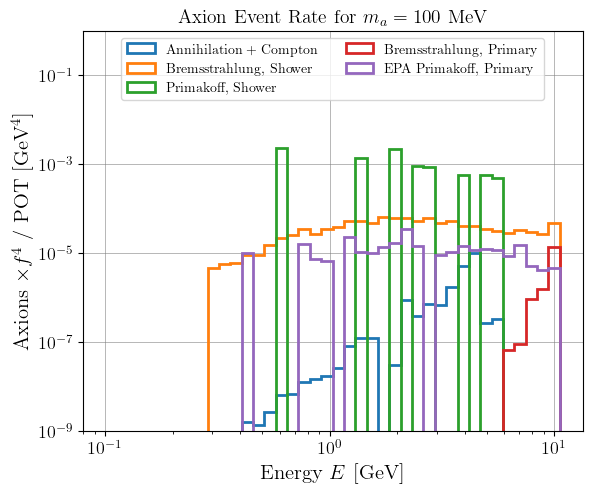

In [3]:
# To obtain smoother curves, more simulations are needed.

AxSh.plot_histo_flux(0.1,ylim=[1e-9,1])

Scanning data to determine optimal energy range for bins...
✅ Plot successfully saved to: /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/DATA_FINAL/Flux.png


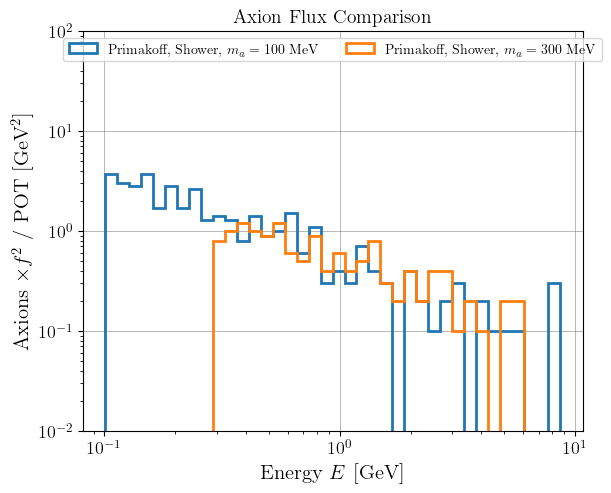

In [4]:
AxSh.plot_histo_flux([0.1,0.3], weights_to_use=['w_prod_rescaled','w_prim'], processes_to_plot=['primakoff_shower'], ylim=[1e-2,1e2], ylabel=r'Axions $\times f^2$ / POT $[{\rm GeV}^{2}]$')

## Sensitivity Curves

The method `plot_sensitivities` allows to produce the sensitivity projections curves. As a mandatory argument, the path to the sensitivity folder must be provided. It takes also a dictionary of parameters with the graphic specs of the curves. 

In the following, an example usage from FIG. 5/6 of https://arxiv.org/pdf/2509.14310. The data are in the folder `SENS_paper`.

### SHiP (Fig.5)

In [9]:
params_all_ydom = {
    'Combined': {
        'label': 'Total',
        'color': 'k',
        'close_curve': True,
        'plot': True,
        'fill': True,
        'line_specs':{
            'linestyle': '--',
            'zorder': 11,
            'linewidth':1.5
        },
         'fill_specs':{
            'zorder': 9,
            'alpha':0.05
        },
    },
    'Primakoff_primary': {
        'color': 'C2',
        'plot': True,
        'close_curve': True,
        'line_specs':{
            'zorder': 9,
            'linewidth':0.8,
            'linestyle': '',
            'label':'_nolegend_'
        },
        'fill_specs':{
            'zorder': 9,
            'alpha':0.20,
            'label': 'Primakoff (Primary)',
        },
    },
        
    'Primakoff_shower': {
        'label': 'Primakoff (Shower)',
        'color': 'C1',
        'plot_low': True,
        'plot_up': False, 
        'fill': False, 
        'ma_max': 1,
        'line_specs':{
            'zorder': 10
        },
    }
}

params_all_edom= params_all_ydom |  {'Ann_Comp': {
        'label': 'Annihilation/Compton (Shower)',
        'color': 'C4',
        'plot_low': True,
        'plot_up': False, 
        'fill': False,
        'ma_max': 0.1
    },
    'Brem_Shower': {
        'label': 'Bremsstrahlung (Shower)',
        'color': 'C0',
        'plot_low': True,
        'plot_up': False, 
        'fill': False,
        'ma_max': 0.1
    }
}

[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/SENS_paper/SHiP/edom/sensitivity_Ann_Comp.pkl.
[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/SENS_paper/SHiP/edom/sensitivity_Brem_Shower.pkl.
[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/SENS_paper/SHiP/edom/sensitivity_Combined.pkl.
[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/SENS_paper/SHiP/edom/sensitivity_Primakoff_primary.pkl.
[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/SENS_paper/SHiP/edom/sensitivity_Primakoff_shower.pkl.
🎨 Plotting order: ['Combined', 'Primakoff_primary', 'Primakoff_shower', 'Ann_Comp', 'Brem_Showe

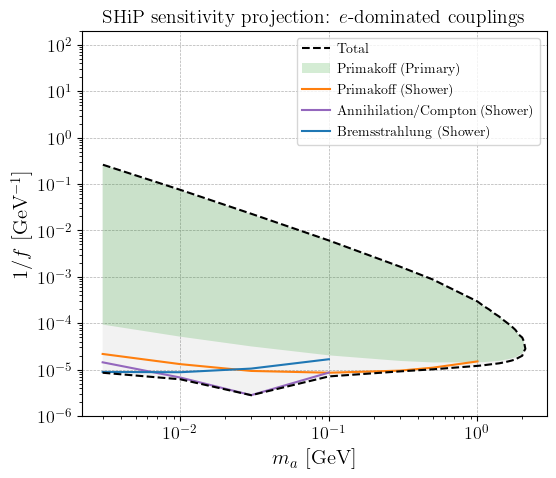

[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/SENS_paper/SHiP/gdom/sensitivity_Combined.pkl.
[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/SENS_paper/SHiP/gdom/sensitivity_Primakoff_primary.pkl.
[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/SENS_paper/SHiP/gdom/sensitivity_Primakoff_shower.pkl.
🎨 Plotting order: ['Combined', 'Primakoff_primary', 'Primakoff_shower']


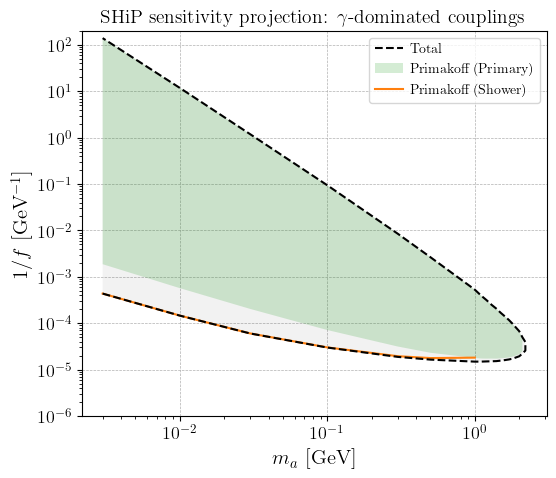

In [11]:
path_sens='SENS_paper/SHiP'
ylim=[1e-6,2e2]
title=r'SHiP sensitivity projection: $e$-dominated couplings'
AxSh.plot_sensitivities(path_sens+'/edom',ylim=ylim,plot_params_map=params_all_edom, title=title, plot_filename=None)

title=r'SHiP sensitivity projection: $\gamma$-dominated couplings'
AxSh.plot_sensitivities(path_sens+'/gdom',ylim=ylim,plot_params_map=params_all_ydom, title=title, plot_filename=None)


### BDX (Fig.6) 

In [14]:
params_all_ydom = {
    'Combined': {
        'label': 'Total',
        'color': 'k',
        'close_curve': True,
        'plot': True,
        'fill': True,
        'skip_masses':[0.9],
        'line_specs':{
            'linestyle': '--',
            'zorder': 11,
            'linewidth':1.5
        },
         'fill_specs':{
            'zorder': 9,
            'alpha':0.05
        },
    },
    'Primary_combined': {
        'color': 'C2',
        'plot': True,
        'close_curve': True,
        'line_specs':{
            'zorder': 9,
            'linewidth':0.8,
            'linestyle': '',
            'label':'_nolegend_'
        },
        'fill_specs':{
            'zorder': 9,
            'alpha':0.20,
            'label': 'Primary (EPA+Brem)',
        },
    },
     'Brem_primary': {
        'color': 'C2',
        'plot': True,
        'close_curve': True,
         'fill':False,
        'line_specs':{
            'zorder': 9,
            'linewidth':0.8,
            'linestyle': ':',
            'label':r'Bremsstralhung (Primary)'
        },
        'fill_specs':{
            'zorder': 9,
            'alpha':0.20,
        },
    },
     'Primakoff_EPA': {
        'color': 'C2',
        'plot': True,
        'close_curve': True,
          'fill':False,
        'line_specs':{
            'zorder': 9,
            'linewidth':0.8,
            'linestyle': '-.',
            'label':r'EPA $\gamma$-fusion (Primary)'
        },
        'fill_specs':{
            'zorder': 9,
            'alpha':0.20,
        },
    },
        
    'Primakoff_shower': {
        'label': 'Primakoff (Shower)',
        'color': 'C1',
        'plot_low': True,
        'plot_up': False, 
        'fill': False, 
        'skip_masses':[0.9],
        'line_specs':{
            'zorder': 10
        },
    }
}

params_all_edom= params_all_ydom |  {'Ann_Comp': {
        'label': 'Annihilation/Compton (Shower)',
        'color': 'C4',
        'plot_low': True,
        'plot_up': False, 
        'fill': False,
        'ma_max': 0.1
    },
    'Brem_Shower': {
        'label': 'Bremsstrahlung (Shower)',
        'color': 'C0',
        'plot_low': True,
        'plot_up': False, 
        'fill': False,
        'ma_max': 0.1
    }
}

[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/SENS_paper/BDX/edom/sensitivity_Ann_Comp.pkl.
[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/SENS_paper/BDX/edom/sensitivity_Brem_Shower.pkl.
[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/SENS_paper/BDX/edom/sensitivity_Brem_primary.pkl.
[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/SENS_paper/BDX/edom/sensitivity_Combined.pkl.
[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/SENS_paper/BDX/edom/sensitivity_Primakoff_EPA.pkl.
[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/d

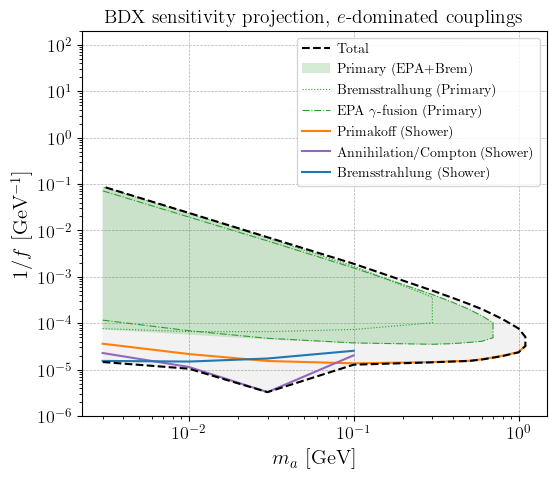

[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/SENS_paper/BDX/gdom/sensitivity_Brem_primary.pkl.
[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/SENS_paper/BDX/gdom/sensitivity_Combined.pkl.
[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/SENS_paper/BDX/gdom/sensitivity_Primakoff_EPA.pkl.
[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/SENS_paper/BDX/gdom/sensitivity_Primakoff_shower.pkl.
[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/SENS_paper/BDX/gdom/sensitivity_Primary_combined.pkl.
🎨 Plotting order: ['Combined', 'Primary_combined', 'Brem_primary', 'Primakoff_EPA', 'Primakoff_

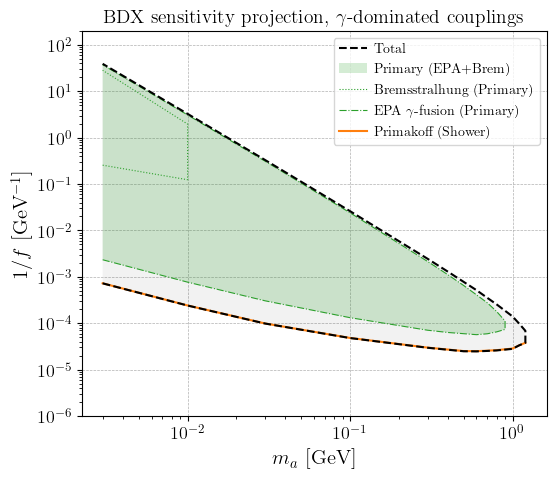

In [15]:
path_sens='SENS_paper/BDX'
ylim=[1e-6,2e2]
title=r'BDX sensitivity projection, $e$-dominated couplings'
AxSh.plot_sensitivities(path_sens+'/edom',ylim=ylim,plot_params_map=params_all_edom, title=title, 
                        plot_filename=None)

title=r'BDX sensitivity projection, $\gamma$-dominated couplings'
AxSh.plot_sensitivities(path_sens+'/gdom',ylim=ylim,plot_params_map=params_all_ydom, title=title, 
                        plot_filename=None)

## Bounds and Projections

To illustrate the versatility of the plotting method, we present also the code used for Fig.7.

[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/SENS_paper/Literature/sensitivity_ALPINIST_NuCal.pkl.
[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/SENS_paper/Literature/sensitivity_BABAR.pkl.
[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/SENS_paper/Literature/sensitivity_Belle.pkl.
[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/SENS_paper/Literature/sensitivity_COSMO.pkl.
[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/data_ALPETITE_tutorial/SENS_paper/Literature/sensitivity_Combined_BDX.pkl.
[load] /Users/samuelpatrone/Desktop/Samuel/PhD/Papers/04 - SHIP ALPs/ALPETITE/PETITE_compatibility_version/da

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/labellines/core.py:267: UserWarning: The value at position 0 in `xvals` is outside the range of its associated line (xmin=0.0029999999999992255, xmax=1.1999999999999984, xval=1.2). Clipping it into the allowed range.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/labellines/core.py:267: UserWarning: The value at position 0 in `xvals` is outside the range of its associated line (xmin=0.0029999999999992255, xmax=2.1999999999999984, xval=4.223104798230276). Clipping it into the allowed range.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/labellines/core.py:267: UserWarning: The value at position 1 in `xvals` is outside the range of its associated line (xmin=0.001201505623721566, xmax=0.458155691949659, xval=8.32200051425637). Clipping it into the allowed range.
  warnings.warn(
/Library/Frameworks/Python.framew

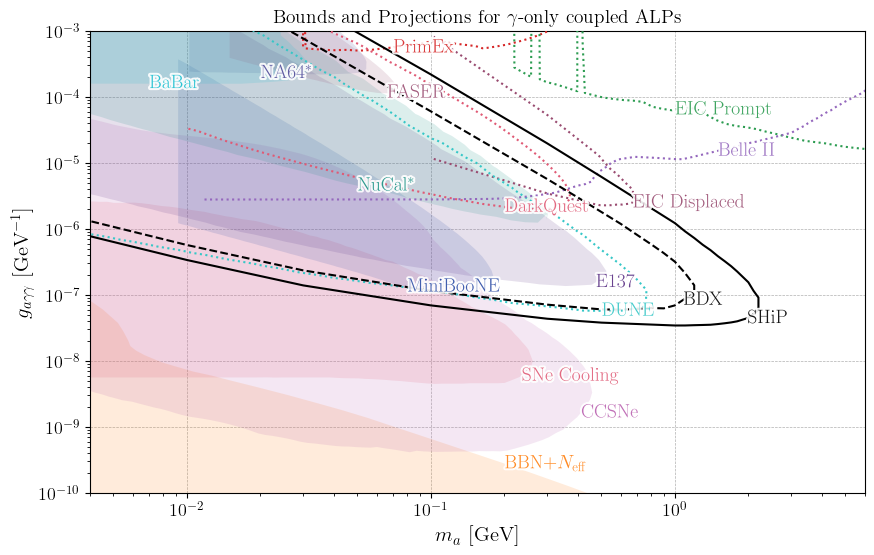

In [17]:
params_tot = {
    # Projections (Highest Z-order, drawn last)
    'Combined_SHIP_6e20': {
        'label': r'SHiP', 'close_curve': True, 'plot': True, 'fill': False, 'named_line': True,
        'color': 'k',
        'line_specs': {'linestyle': '-', 'zorder': 20, 'linewidth': 1.5} # <-- Highest zorder
    },
    'Combined_BDX': {
        'label': r'BDX', 'close_curve': True, 'plot': True, 'fill': False, 'named_line': True, 'label_x_pos': 1.2,
        'color': 'k',
        'line_specs': {'linestyle': '--', 'zorder': 19, 'linewidth': 1.5} # <-- High zorder
    },

    # --- Filled Bounds (Now with explicit Z-order) ---

    'COSMO': {
        'label': r'BBN+$N_\text{eff}$', 'plot': True, 'fill_below': True, 'named_line': True, 'label_x_pos': 0.2,
        'color': 'C1',
        'line_specs': {'linestyle': '', 'zorder': 1} # <-- Draw FIRST
    },
    'SN_1B': {
        'label': 'CCSNe', 'close_curve': True, 'plot': True, 'named_line': True, 'fill':True,
        'color': '#ba61b0',
        'line_specs': {'linestyle': '', 'zorder': 2} # <-- Draw second
    },
    'cooling': {
        'label': 'SNe Cooling', 'close_curve': True, 'plot': True, 'fill': True, 'named_line': True,
        'color': '#e05a75',
        'line_specs': {'linestyle': '', 'zorder': 3} # <-- Draw third
    },
    'E137': {
        'label': r'E137', 'plot': True, 'close_curve': True, 'fill': True, 'named_line': True,
        'color': '#5b3185',
        'line_specs': {'linestyle': '', 'zorder': 4} # <-- Draw as background for messy area
    },
    'miniboone': {
        'label': r'MiniBooNE', 'plot': True, 'fill': True, 'named_line': True, 'label_x_pos': 0.08,
        'color': '#2d4da6',
        'line_specs': {'linestyle': '', 'zorder': 5} # <-- Draw on top of E137
    },
    'NA64': {
        'label': r'NA64$^*$', 'plot': True, 'fill': True, 'close_curve': True, 'named_line': True, 'label_x_pos': 2e-2,
        'color': '#4E4B99',
        'line_specs': {'linestyle': '', 'zorder': 6} # <-- Draw on top of MiniBooNE
    },
    'ALPINIST_NuCal': {
        'label': r'NuCal$^*$', 'plot': True, 'fill': True, 'close_curve': True, 'named_line': True, 'label_x_pos': 0.05,
        'color': '#178f83',
        'line_specs': {'linestyle': '', 'zorder': 7} # <-- Draw on top of the blues
    },
    'FASER': {
        'label': r'FASER', 'plot': True, 'fill': True, 'named_line': True,
        'color': '#994b70',
        'line_specs': {'linestyle': '', 'zorder': 8} # <-- Draw LAST among filled regions
    },
    
    # --- Unfilled Lines/Projections ---
    
    'EIC_10fb': {
        'label': r'EIC Prompt', 'plot': True, 'fill_above': False, 'named_line': True, 'label_x_pos': 1,
        'color': '#2c9c51',
        'line_specs': {'linestyle': ':', 'zorder': 15}
    },
    'EIC_DV': {
        'label': r'EIC Displaced', 'plot': True, 'close_curve': True, 'fill': False, 'named_line': True, 'label_x_pos': 0.67,
        'color': '#994B70',
        'line_specs': {'linestyle': ':', 'zorder': 15}
    },
    'DUNE': {
        'label': r'DUNE', 'plot': True, 'fill': False, 'named_line': True, 'close_curve': True, 'label_x_pos': 0.5,
        'color': '#36c7c7',
        'line_specs': {'linestyle': ':', 'zorder': 15}
    },
    'DarkQuest': {
        'label': r'DarkQuest', 'plot': True, 'fill': False, 'named_line': True, 'close_curve': True, 'label_x_pos': 2e-1,
        'color': '#e05a75',
        'line_specs': {'linestyle': ':', 'zorder': 15}
    },
    'Belle': {
        'label': r'Belle II', 'plot': True, 'fill': False, 'named_line': True, 'label_x_pos': 1.5,
        'color': 'C4',
        'line_specs': {'linestyle': ':', 'zorder': 15}
    },
    'LUXE': {
        'label': r'LUXE', 'plot': False, 'fill': False, 'named_line': True, 'label_x_pos': 1e-1,
        'color': '#cc9352', 'line_specs': {'linestyle': ':'}
    },
    'Primex': {
        'label': r'PrimEx', 'plot': True, 'fill_above': False, 'named_line': True,
        'color': 'C3', 'line_specs': {'linestyle': ':'}, 'label_x_pos': 7e-2,
    },
    'BABAR': {
        'label': r'BaBar', 'plot': True, 'fill': True, 'named_line': True,
        'color': 'C9', 'line_specs': {'linestyle': ''},'label_x_pos': 7e-3,
    },
}


title=r'Bounds and Projections for $\gamma$-only coupled ALPs'

ylim=[1e-10,1e-3]
AxSh.plot_sensitivities('SENS_paper/Literature',plot_params_map=params_tot, 
                        title=title, 
                        plot_filename=None,
                        y_label=r'$g_{a\gamma\gamma}~[\text{GeV}^{-1}]$', 
                        malim=[0.004,6],
                        ylim=ylim,w=10,h=6)
